# ```Are Prices Justified? - IPL 2026```

## 1.Data Import

### 1.1 Data Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
batters = pd.read_excel(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\IPL_2026_Combined_Data.xlsx",
                        sheet_name="Batting Stats",)

bowlers = pd.read_excel(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\IPL_2026_Combined_Data.xlsx",
                        sheet_name="Bowling Stats",)

prices = pd.read_excel(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\IPL_2026_Combined_Data.xlsx",
                        sheet_name="Auction Prices",)

In [3]:
batters.head()

,POS,Player,Team,Runs,Mat,Inns,NO,HS,Avg,BF,SR,100,50,4s,6s
0,1,Vaibhav Sooryavanshi,RR,776,16,16,0,103,48.5,327,237.30,1,5,63,72
1,2,Shubman Gill,GT,732,16,16,0,104,45.75,449,163.02,1,6,74,33
2,3,Sai Sudharsan,GT,722,17,17,1,100,45.13,457,157.98,1,8,75,30
3,4,Virat Kohli,RCB,675,16,16,4,105*,56.25,407,165.84,1,5,73,25
4,5,Heinrich Klaasen,SRH,624,15,15,2,69,48,390,160.00,0,6,48,31


In [4]:
bowlers.head()

,POS,Player,Team,Wkts,Mat,Inns,Ov,Runs,BBI,Avg,Econ,SR,4w,5w
0,1,Kagiso Rabada,GT,29,17,17,64.4,626,25/3,21.58,9.68,13.37,0,0
1,2,Bhuvneshwar Kumar,RCB,28,16,16,63.0,501,23/4,17.89,7.95,13.50,1,0
2,3,Jofra Archer,RR,25,16,16,60.0,559,17/3,22.36,9.31,14.40,0,0
3,4,Rashid Khan,GT,21,17,17,56.5,516,33/4,24.57,9.07,16.23,1,0
4,5,Anshul Kamboj,CSK,21,14,14,50.2,530,22/3,25.23,10.52,14.38,0,0


In [5]:
prices.head()

,Player,Auction_Year,Base_Price,Final_Price,Currency,Auction_Team,Role,Matched_Name_In_Auction
0,Abdul Samad,2025,3000000,42000000,INR,Lucknow Super Giants,Uncapped,Abdul Samad
1,Abhinandan Singh,2025,3000000,3000000,INR,Royal Challengers Bengaluru,Uncapped,Abhinandan Singh
2,Abhishek Sharma,2022,2000000,65000000,INR,Sunrisers Hyderabad,Capped,Abhishek Sharma
3,Adam Milne,2026,20000000,24000000,INR,Rajasthan Royals,Capped,Adam Milne
4,Aiden Markram,2025,20000000,20000000,INR,Lucknow Super Giants,Capped,Aiden Markram


### 1.2 Data Overview

In [6]:
batters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   POS     167 non-null    int64  
 1   Player  167 non-null    object 
 2   Team    167 non-null    object 
 3   Runs    167 non-null    int64  
 4   Mat     167 non-null    int64  
 5   Inns    167 non-null    int64  
 6   NO      167 non-null    int64  
 7   HS      167 non-null    object 
 8   Avg     167 non-null    object 
 9   BF      167 non-null    int64  
 10  SR      167 non-null    float64
 11  100     167 non-null    int64  
 12  50      167 non-null    int64  
 13  4s      167 non-null    int64  
 14  6s      167 non-null    int64  
dtypes: float64(1), int64(10), object(4)
memory usage: 19.7+ KB


In [7]:
bowlers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   POS     104 non-null    int64  
 1   Player  104 non-null    object 
 2   Team    104 non-null    object 
 3   Wkts    104 non-null    int64  
 4   Mat     104 non-null    int64  
 5   Inns    104 non-null    int64  
 6   Ov      104 non-null    float64
 7   Runs    104 non-null    int64  
 8   BBI     104 non-null    object 
 9   Avg     104 non-null    float64
 10  Econ    104 non-null    float64
 11  SR      104 non-null    float64
 12  4w      104 non-null    int64  
 13  5w      104 non-null    int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 11.5+ KB


In [8]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Player                   178 non-null    object
 1   Auction_Year             178 non-null    int64 
 2   Base_Price               178 non-null    int64 
 3   Final_Price              178 non-null    int64 
 4   Currency                 178 non-null    object
 5   Auction_Team             178 non-null    object
 6   Role                     178 non-null    object
 7   Matched_Name_In_Auction  173 non-null    object
dtypes: int64(3), object(5)
memory usage: 11.3+ KB


In [9]:
batters.describe().reset_index().T

,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
POS,167.0,84.0,48.35287,1.0,42.5,84.0,125.5,167.0
Runs,167.0,156.592814,185.535732,1.0,12.5,65.0,266.0,776.0
Mat,167.0,9.628743,4.757355,1.0,6.0,10.0,14.0,17.0
Inns,167.0,6.736527,4.974881,1.0,2.0,5.0,11.0,17.0
NO,167.0,1.526946,1.508268,0.0,0.0,1.0,2.0,8.0
BF,167.0,100.065868,109.868988,1.0,12.0,52.0,168.5,457.0
SR,167.0,135.634491,48.185031,16.66,114.155,139.65,163.15,350.0
100,167.0,0.08982,0.307072,0.0,0.0,0.0,0.0,2.0
50,167.0,0.922156,1.624341,0.0,0.0,0.0,1.0,8.0


In [10]:
bowlers.describe().reset_index().T

,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
POS,104.0,52.5,30.166206,1.0,26.75,52.5,78.25,104.0
Wkts,104.0,8.028846,6.43633,1.0,2.0,6.0,12.0,29.0
Mat,104.0,8.875,4.771858,1.0,4.75,9.0,13.0,17.0
Inns,104.0,7.788462,4.618816,1.0,3.75,7.0,12.0,17.0
Ov,104.0,25.691346,17.521039,1.0,9.85,24.2,39.375,64.4
Runs,104.0,249.692308,159.631802,7.0,101.0,249.0,382.0,626.0
Avg,104.0,38.853558,22.289444,7.0,25.0,32.72,44.85,141.0
Econ,104.0,10.117308,1.549985,6.64,9.0,9.96,11.2,14.0
SR,104.0,23.002981,12.988723,6.0,15.3675,19.685,24.0,90.0


In [11]:
prices.describe().reset_index().T

,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
Auction_Year,178.0,2024.41573,2.004565,2014.0,2025.0,2025.0,2025.0,2026.0
Base_Price,178.0,9926966.292135,7755461.192943,1000000.0,3000000.0,6250000.0,20000000.0,20000000.0
Final_Price,178.0,44514044.94382,55097792.612569,1000000.0,6125000.0,20000000.0,65000000.0,270000000.0


## 2.Data Cleaning

In [12]:
batters.columns = batters.columns.str.lower()
bowlers.columns = bowlers.columns.str.lower()
prices.columns = prices.columns.str.lower()

In [13]:
batters.head()

,pos,player,team,runs,mat,inns,no,hs,avg,bf,sr,100,50,4s,6s
0,1,Vaibhav Sooryavanshi,RR,776,16,16,0,103,48.5,327,237.30,1,5,63,72
1,2,Shubman Gill,GT,732,16,16,0,104,45.75,449,163.02,1,6,74,33
2,3,Sai Sudharsan,GT,722,17,17,1,100,45.13,457,157.98,1,8,75,30
3,4,Virat Kohli,RCB,675,16,16,4,105*,56.25,407,165.84,1,5,73,25
4,5,Heinrich Klaasen,SRH,624,15,15,2,69,48,390,160.00,0,6,48,31


In [14]:
batters[batters['avg'].str.contains("-",na=False)].head()

,pos,player,team,runs,mat,inns,no,hs,avg,bf,sr,100,50,4s,6s
90,91,Shahbaz Ahamad,LSG,58,5,2,2,43*,-,41,141.46,0,0,4,3
101,102,Bhuvneshwar Kumar,RCB,34,16,4,4,15*,-,26,130.76,0,0,3,1
108,109,Mitchell Santner,MI,26,4,2,2,18*,-,19,136.84,0,0,3,0
114,115,Madhav Tiwari,DC,18,3,1,1,18*,-,8,225.00,0,0,2,1
119,120,Vishnu Vinod,PBKS,15,1,1,1,15*,-,8,187.50,0,0,1,1


In [ ]:
mask = batters['avg'].astype(str).str.contains('-', na=False)
batters.loc[mask & (batters['inns'] > batters['no']), 'avg'] = (
    batters['runs'] / (batters['inns'] - batters['no'])
)
batters.loc[mask & (batters['inns'] == batters['no']), 'avg'] = batters['runs']

In [16]:
batters['avg'] = batters['avg'].astype(float)

In [17]:
batters['avg'].describe()

count    167.000000
mean      21.637605
std       15.916652
min        1.000000
25%        7.000000
50%       19.220000
75%       33.945000
max       66.500000
Name: avg, dtype: float64

In [18]:
prices.drop(columns="matched_name_in_auction",inplace=True)

In [19]:
batters['hs']=batters['hs'].str.replace("*","").astype(int)

In [20]:
batters.sample(3)

,pos,player,team,runs,mat,inns,no,hs,avg,bf,sr,100,50,4s,6s
52,53,Hardik Pandya,MI,206,10,10,1,40,22.89,149,138.25,0,0,21,7
163,164,Vaibhav Arora,KKR,1,11,2,2,1,1.00,3,33.33,0,0,0,0
149,150,Ravi Singh,RR,4,1,1,0,4,4.00,2,200.00,0,0,1,0


In [21]:
bowlers.sample(3)

,pos,player,team,wkts,mat,inns,ov,runs,bbi,avg,econ,sr,4w,5w
59,60,Digvesh Singh,LSG,5,10,10,39.0,397,45/2,79.4,10.17,46.8,0,0
80,81,Will Jacks,MI,2,7,6,8.5,94,12/1,47.0,10.64,26.5,0,0
75,76,Harpreet Brar,PBKS,2,2,2,8.0,60,35/2,30.0,7.50,24.0,0,0


In [22]:
prices.sample(3)

,player,auction_year,base_price,final_price,currency,auction_team,role
110,Rajat Patidar,2021,2000000,2000000,INR,Royal Challengers Bengaluru,Capped
151,Tejasvi Singh,2026,3000000,30000000,INR,Kolkata Knight Riders,Uncapped
17,Ashutosh Sharma,2025,3000000,38000000,INR,Delhi Capitals,Uncapped


In [35]:
batters.isnull().sum()

pos               0
player            0
team              0
runs              0
mat               0
inns              0
no                0
hs                0
avg               0
bf                0
sr                0
100               0
50                0
4s                0
6s                0
boundary_pct      0
avg_balls_inns    0
got_chance_pct    0
dtype: int64

In [36]:
bowlers.isnull().sum()

pos               0
player            0
team              0
wkts              0
mat               0
inns              0
ov                0
runs              0
bbi               0
avg               0
econ              0
sr                0
4w                0
5w                0
got_chance_pct    0
dtype: int64

In [37]:
prices.isnull().sum()

player              0
auction_year        0
base_price          0
final_price         0
currency            0
auction_team        0
role                0
final_price_rate    0
dtype: int64

## 3.Feature Engineering

In [ ]:
batters['boundary_pct']=(((batters['4s']*4 + batters['6s']*6)/batters['runs'])*100).round(2)

In [24]:
batters['avg_balls_inns']=(batters['bf']/batters['inns']).round(2)

In [25]:
batters['got_chance_pct']=(batters['inns']/batters['mat']).mul(100).round(2)

In [26]:
bowlers['got_chance_pct']=(bowlers['inns']/bowlers['mat']).mul(100).round(2)

In [27]:
prices['final_price_rate']=(prices['final_price']/prices['base_price']).round(2)

In [28]:
batters.head(3)

,pos,player,team,runs,mat,inns,no,hs,avg,bf,sr,100,50,4s,6s,boundary_pct,avg_balls_inns,got_chance_pct
0,1,Vaibhav Sooryavanshi,RR,776,16,16,0,103,48.50,327,237.30,1,5,63,72,88.14,20.44,100.0
1,2,Shubman Gill,GT,732,16,16,0,104,45.75,449,163.02,1,6,74,33,67.49,28.06,100.0
2,3,Sai Sudharsan,GT,722,17,17,1,100,45.13,457,157.98,1,8,75,30,66.48,26.88,100.0


In [29]:
bowlers.head(3)

,pos,player,team,wkts,mat,inns,ov,runs,bbi,avg,econ,sr,4w,5w,got_chance_pct
0,1,Kagiso Rabada,GT,29,17,17,64.4,626,25/3,21.58,9.68,13.37,0,0,100.0
1,2,Bhuvneshwar Kumar,RCB,28,16,16,63.0,501,23/4,17.89,7.95,13.50,1,0,100.0
2,3,Jofra Archer,RR,25,16,16,60.0,559,17/3,22.36,9.31,14.40,0,0,100.0


In [30]:
prices.head(3)

,player,auction_year,base_price,final_price,currency,auction_team,role,final_price_rate
0,Abdul Samad,2025,3000000,42000000,INR,Lucknow Super Giants,Uncapped,14.0
1,Abhinandan Singh,2025,3000000,3000000,INR,Royal Challengers Bengaluru,Uncapped,1.0
2,Abhishek Sharma,2022,2000000,65000000,INR,Sunrisers Hyderabad,Capped,32.5


In [38]:
batters_merged = batters.merge(prices[['player','auction_year','base_price','final_price','role','final_price_rate']],on='player',how='right')

In [39]:
bowlers_merged = bowlers.merge(prices[['player','auction_year','base_price','final_price','role','final_price_rate']],on='player',how='right')

In [40]:
batters_merged.head()

,pos,player,team,runs,mat,inns,no,hs,avg,bf,...,4s,6s,boundary_pct,avg_balls_inns,got_chance_pct,auction_year,base_price,final_price,role,final_price_rate
0,71.0,Abdul Samad,LSG,116.0,8.0,8.0,2.0,37.0,19.33,88.0,...,10.0,5.0,60.34,11.00,100.00,2025,3000000,42000000,Uncapped,14.0
1,NaN,Abhinandan Singh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2025,3000000,3000000,Uncapped,1.0
2,8.0,Abhishek Sharma,SRH,563.0,15.0,15.0,1.0,135.0,40.21,275.0,...,50.0,43.0,81.35,18.33,100.00,2022,2000000,65000000,Capped,32.5
3,156.0,Adam Milne,RR,2.0,1.0,1.0,1.0,2.0,2.00,2.0,...,0.0,0.0,0.00,2.00,100.00,2026,20000000,24000000,Capped,1.2
4,46.0,Aiden Markram,LSG,231.0,12.0,11.0,2.0,45.0,25.67,167.0,...,20.0,11.0,63.20,15.18,91.67,2025,20000000,20000000,Capped,1.0


In [41]:
batters_merged = batters_merged[batters_merged['mat'].notna()]

In [42]:
batters_merged.head()

,pos,player,team,runs,mat,inns,no,hs,avg,bf,...,4s,6s,boundary_pct,avg_balls_inns,got_chance_pct,auction_year,base_price,final_price,role,final_price_rate
0,71.0,Abdul Samad,LSG,116.0,8.0,8.0,2.0,37.0,19.33,88.0,...,10.0,5.0,60.34,11.00,100.00,2025,3000000,42000000,Uncapped,14.0
2,8.0,Abhishek Sharma,SRH,563.0,15.0,15.0,1.0,135.0,40.21,275.0,...,50.0,43.0,81.35,18.33,100.00,2022,2000000,65000000,Capped,32.5
3,156.0,Adam Milne,RR,2.0,1.0,1.0,1.0,2.0,2.00,2.0,...,0.0,0.0,0.00,2.00,100.00,2026,20000000,24000000,Capped,1.2
4,46.0,Aiden Markram,LSG,231.0,12.0,11.0,2.0,45.0,25.67,167.0,...,20.0,11.0,63.20,15.18,91.67,2025,20000000,20000000,Capped,1.0
5,27.0,Ajinkya Rahane,KKR,335.0,14.0,14.0,1.0,67.0,25.77,248.0,...,25.0,18.0,62.09,17.71,100.00,2025,15000000,15000000,Capped,1.0


In [43]:
bowlers_merged = bowlers_merged[bowlers_merged['mat'].notna()]

In [45]:
bowlers_merged.head()

,pos,player,team,wkts,mat,inns,ov,runs,bbi,avg,econ,sr,4w,5w,got_chance_pct,auction_year,base_price,final_price,role,final_price_rate
1,75.0,Abhinandan Singh,RCB,3.0,3.0,3.0,9.4,122.0,30/2,40.66,12.62,19.33,0.0,0.0,100.00,2025,3000000,3000000,Uncapped,1.00
6,72.0,Akash Singh,LSG,4.0,2.0,2.0,7.0,80.0,26/3,20.00,11.42,10.50,0.0,0.0,100.00,2025,3000000,3000000,Uncapped,1.00
7,44.0,Akeal Hosein,CSK,8.0,7.0,7.0,24.4,198.0,17/4,24.75,8.02,18.50,1.0,0.0,100.00,2026,20000000,20000000,Capped,1.00
11,5.0,Anshul Kamboj,CSK,21.0,14.0,14.0,50.2,530.0,22/3,25.23,10.52,14.38,0.0,0.0,100.00,2025,3000000,34000000,Uncapped,11.33
12,39.0,Anukul Roy,KKR,9.0,14.0,12.0,27.1,261.0,31/2,29.00,9.60,18.11,0.0,0.0,85.71,2025,3000000,4000000,Uncapped,1.33


## 4.Data Analysis

### 4.1 Univariate Analysis

In [82]:
def plot_kde(data,columns):
    for col in columns:
        plt.figure(figsize=(24,5))
        sns.kdeplot(x= col,data=data,linewidth = 3,color='teal',fill=True)
        plt.axvline(data[col].min(),color = 'red',linestyle = '--',label = f'minimum {col}')
        plt.axvline(data[col].quantile(.95),color = 'green',linestyle = '--',label = f'95th percentile {col}')
        plt.axvline(data[col].median(),color = 'yellow',linestyle = '--',label = f'median {col}')
        plt.title(f"{col} Dist For Batters",weight='bold')
        plt.legend()
        plt.show()

**Batters**

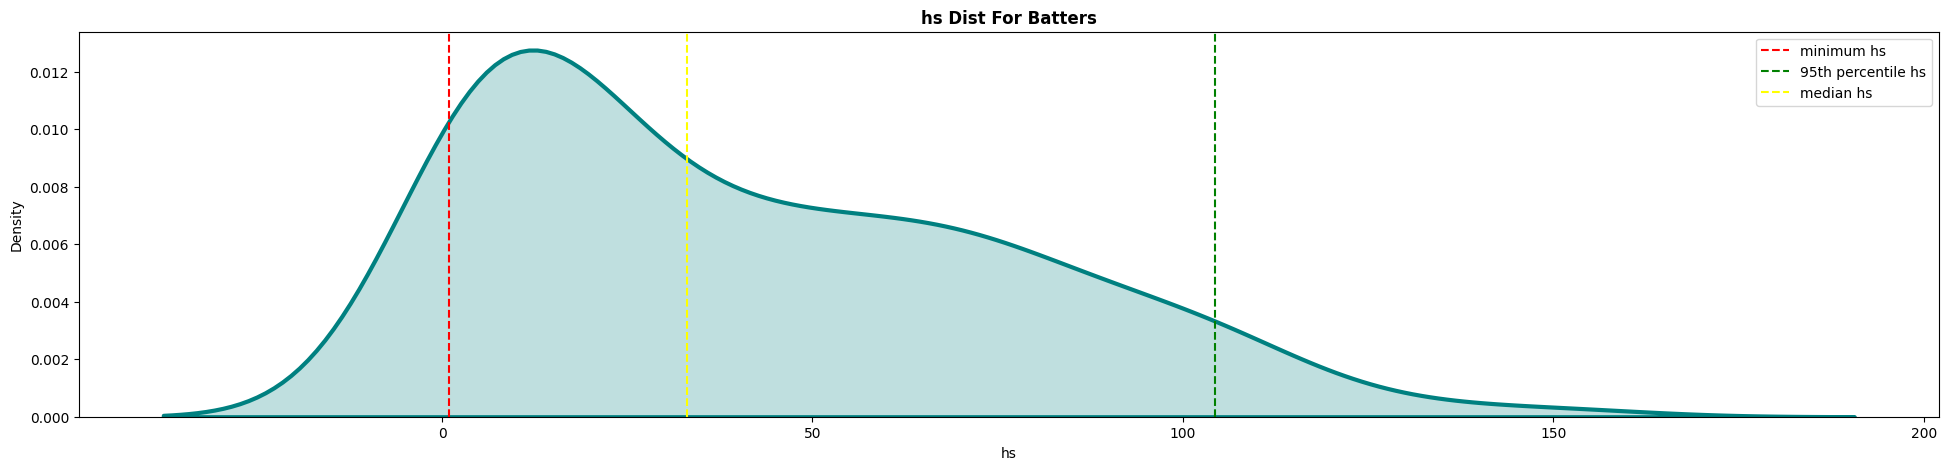

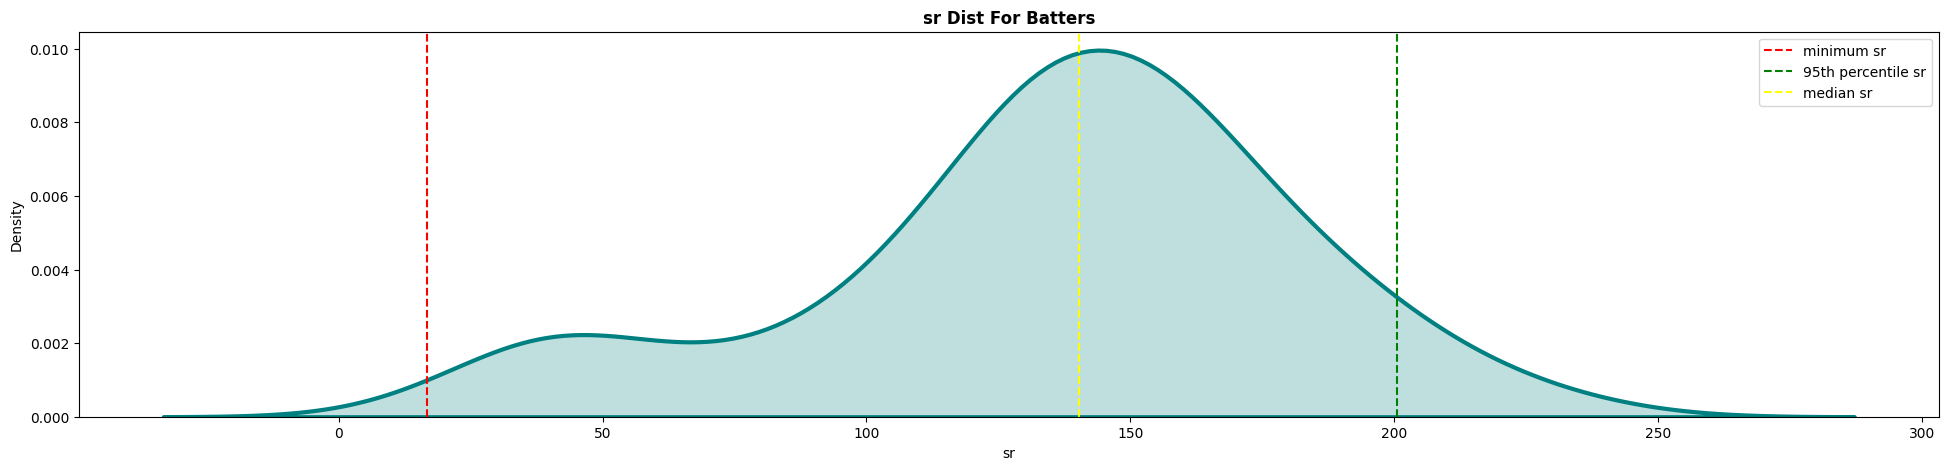

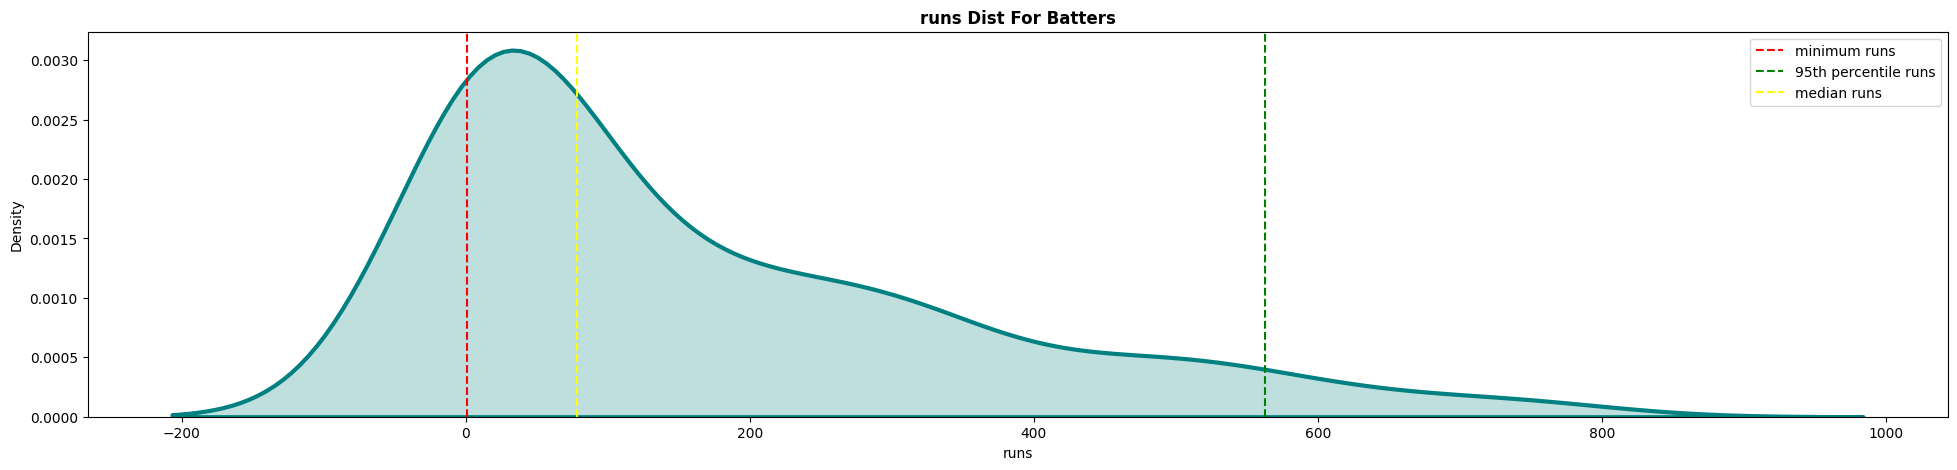

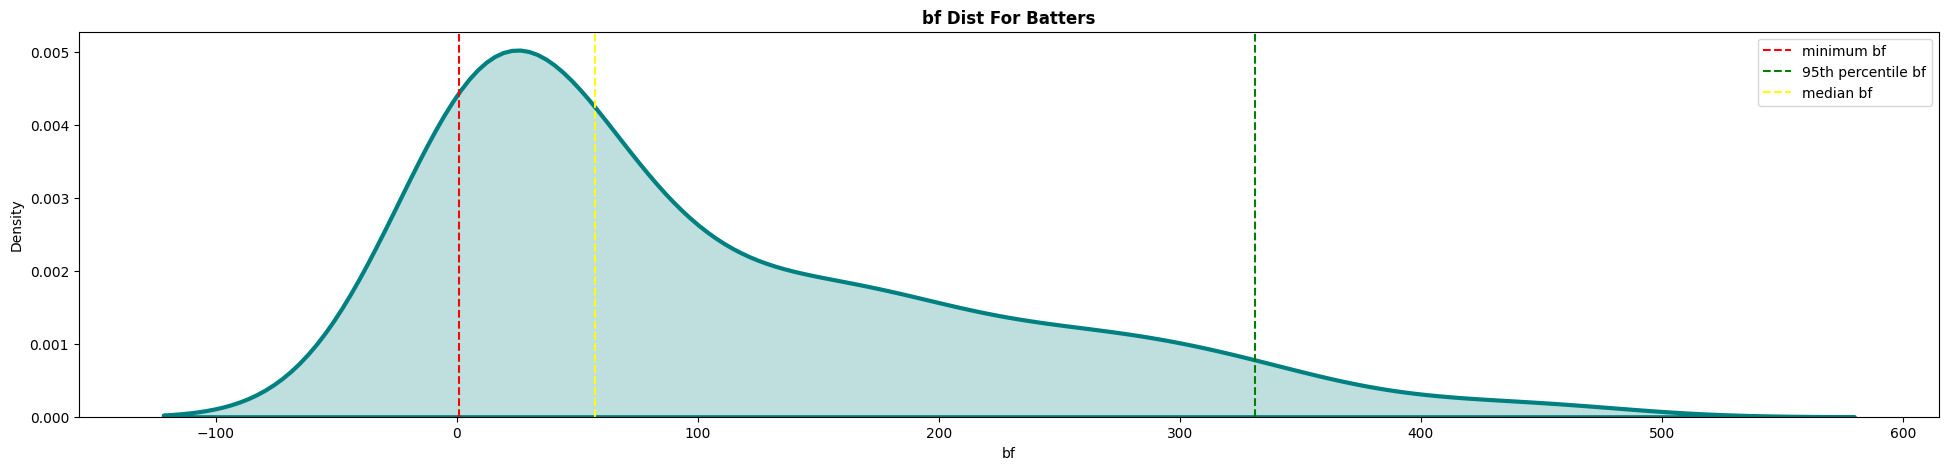

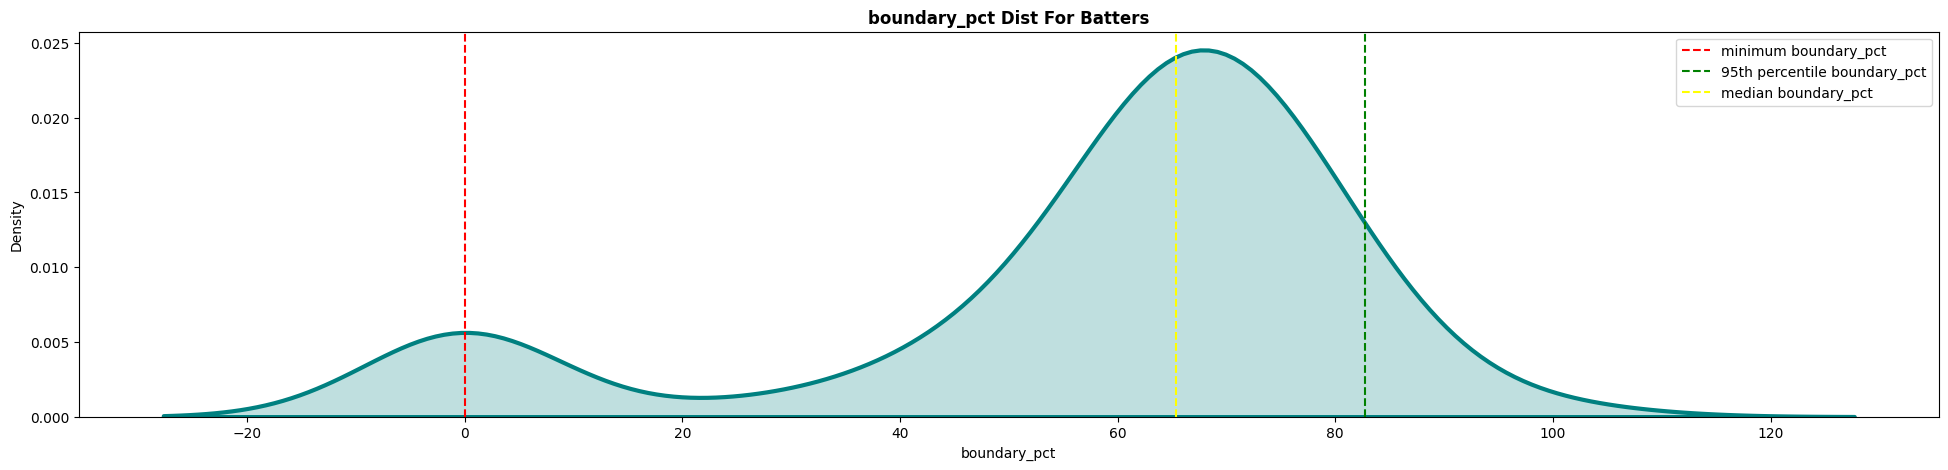

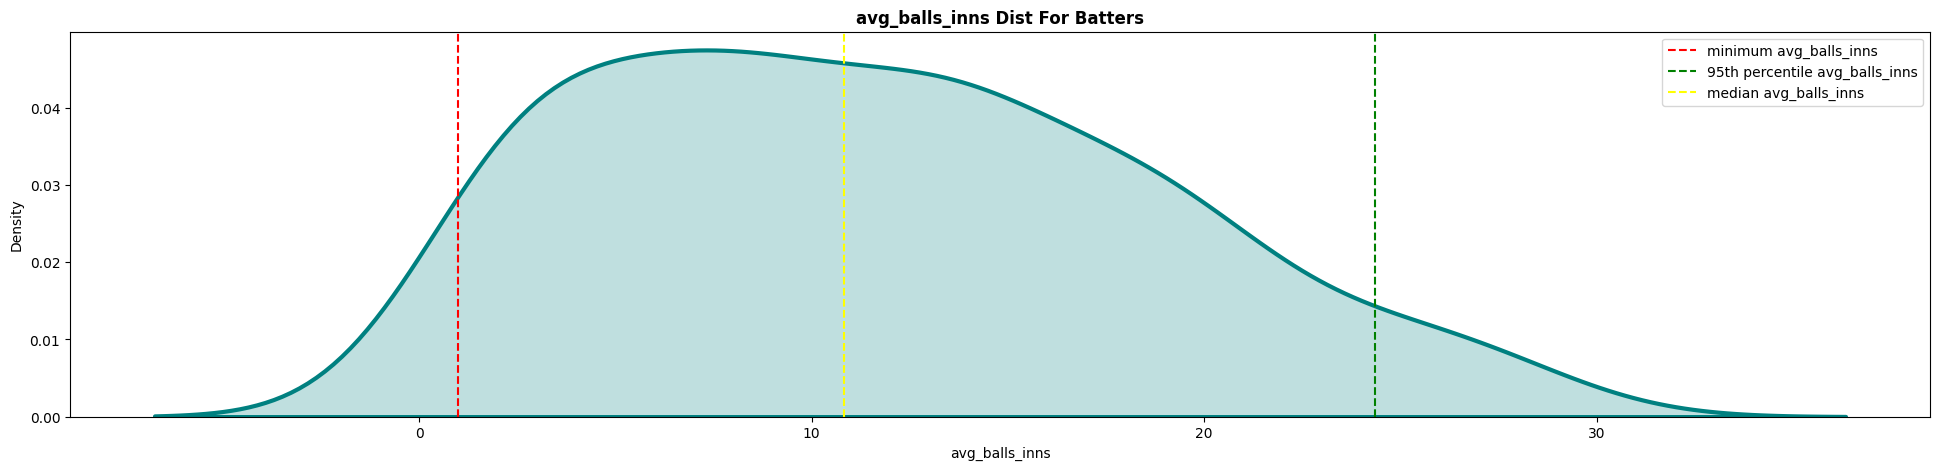

In [84]:
columns = ['hs','sr','runs','bf','boundary_pct','avg_balls_inns']
plot_kde(batters_merged,columns=columns)


### 4.2 Bivariate Analysis

## 5.Justification

### 5.1 Batters

5.1.1 Capped

5.1.2 Uncapped

### 6.1 Bowlers

6.1.1 Capped

6.1.2 Uncapped